# **Marketing ROI Analytics Pipeline with PySpark**

# To what extent do email communications influence cinema visits or customer spending?

- Do customers who receive more emails go to the cinema more often?
- Do emails increase the number of tickets sold or the average spend?
- Does the effect depend on the type of movie, theater, or season?

## **Executive summary**

### **Findings summary**

1. Emails sent in the last 3 days have a very small effect on the likelihood of purchase and daily spending.
2. Longer-term email exposure (last 30 days) shows a slightly positive association with purchase probability but minimal impact on spending.
3. Customer age segments appear correlated with emails received and total spend, but further analysis is needed.
4. Weekend attendance increases purchase probability and spending, indicating timing matters for engagement.
5. New movie releases significantly drive both purchase likelihood and amount spent, outweighing email effects.

### **Suggestions**

1. Target emails strategically around weekends and new releases to maximize potential engagement and impact.
2. Focus marketing efforts on high-value or recently active customers, leveraging historical spending and ticket purchase patterns.
3. Consider email campaigns as supportive engagement tools rather than primary drivers of immediate sales; pair them with other incentives or promotions to enhance effectiveness.


## **Datasets**

| Dataset              | Columns                                                        | Meaning                                                                                         
| -------------------- | ------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------
| **Transactions.csv** | `CARD_MEMBERSHIPID`, `ID_CINE`, `TX_PELICULA_UNICA`,`FECHA_TRANSACCION`,  `BOLETOS`, `IMPORTE_TAQUILLA` | Cada fila parece ser una compra (uno o más boletos) de un cliente, para una película y cine específico | Fuente para medir **visitas** (conteo de transacciones o boletos) y **gasto** (`IMPORTE_TAQUILLA`) |
| **Pricebook.csv**    | `ID_CINE`, `ANIO`, `PRECIO_POL_R`                                                        | Precio regular adulto (`PRECIO_POL_R`) para cada cine y año                                            | Control de **variación de precios** entre cines y años                                             |
| **Customers.csv**    | `CARD_MEMBERSHIPID`, `SubscriberKeyH`, `DATE_OF_BIRTH`                   | Mapeo entre ID de cliente interno y su ID de email + edad aproximada                                   | Permite unir clientes con correos y segmentar por edad                                             |
| **Emails.csv**       | `SubscriberKeyH`, `EventDate`, `SendId`                                  | Cada fila es un correo enviado a un cliente                                                            | Fuente de exposición: **número y frecuencia de correos**                                           |
| **Releases.csv**     | `TX_PELICULA_UNICA`, `ESTRENO`, `VENTAS`                                 | Fecha de estreno y ventas totales por película                                                         | Control de estacionalidad y **efecto contenido**                                                   |


### **Hypotheses**

### H1 — Email exposure increases purchase probability

> Customers who receive emails may be more likely to make a purchase in the following days.

* **Variables:** `received_email_last_X_days`, `purchased_on_day`
* **Model type:** Logistic regression
* **Control variables:** `customer_age`, `avg_daily_spent_last_30days`, `is_weekend`

---

### H2 — Email exposure increases average spending

> Among customers who make a purchase, emails might influence how much they spend or the number of tickets they buy.

* **Variables:** `received_email_last_X_days`, `daily_spent`, `daily_tickets`
* **Model type:** Linear regression
* **Controls:** `avg_daily_spent_last_30days`, `customer_age`, `is_new_release`

---

### H3 — Email effect varies by customer segment

> Different customer groups (e.g., by age or purchase frequency) may respond differently to email campaigns.

* **Variables:** interaction between `received_email_last_X_days`, `customer_age`, and `is_weekend`
* **Model type:** Logistic or linear regression with interaction terms



### **Derived Variables (Feature Engineering Plan)**

| Variable (Nombre Final)           | Descripción / Lógica de Cálculo                                                                                                  | Tipo de Dato |
|----------------------------------|----------------------------------------------------------------------------------------------------------------------------------|---------------|
| received_email                   | 1 si el cliente recibió un correo electrónico relevante para la transacción; 0 en caso contrario.                              | integer       |
| received_email_last_3days        | 1 si el cliente recibió al menos un correo en los 3 días previos a la fecha de transacción; 0 en caso contrario.                 | long          |
| purchased_on_day                 | 1 si el cliente realizó alguna compra en ese día; 0 en caso contrario.                                                          | integer       |
| daily_spent                      | Monto total gastado por el cliente en ese día.                                                          | double        |
| daily_tickets                    | Número total de boletos comprados por el cliente en ese día.                                                     | long          |
| customer_age                     | Edad del cliente, calculada como 2024 – año de nacimiento.                                                                      | integer       |
| is_new_release                   | 1 si la película se estrenó en los 7 días previos a la transacción; 0 en caso contrario.                                        | integer       |
| received_email_last_30days       | Número total de correos que el cliente recibió en los 30 días previos a la transacción.                                         | long          |
| received_email_last_30days_flag  | 1 si el cliente recibió al menos un correo en los últimos 30 días; 0 en caso contrario.                                      | integer       |
| last_email_date                  | Fecha del último correo electrónico recibido por el cliente antes de la transacción.                                            | date          |
| days_since_last_email            | Número de días entre el último correo recibido y la fecha de la transacción.                                                    | integer       |
| avg_daily_spent_last_30days      | Gasto promedio diario del cliente en los 30 días previos a la transacción. Un proxy del valor histórico.                       | double        |
| avg_tickets_last_30days          | Promedio de boletos comprados por el cliente en los 30 días previos a la transacción.                                           | double        |
| is_weekend                       | 1 si el día analizado es fin de semana; 0 en caso contrario                                 | integer       |


## **Code**

## Libraries

In [1]:
# ── 1. IMPORTS ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, lit, explode, sequence, to_date,
    count, sum as Fsum, avg as Favg,
    year, broadcast, when, dayofweek
)
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator



In [2]:
# Cargamos los datasets en pandas para manejarlos de manera más sencilla
transactions = pd.read_csv("Transactions.csv")
pricebook    = pd.read_csv("Pricebook.csv")
customers    = pd.read_csv("Customers.csv")
emails       = pd.read_csv("Emails.csv")
releases     = pd.read_csv("Releases.csv")

In [3]:
transactions.head()

,ID_CINE,FECHA_TRANSACCION,FECHA_FUNCION,CARD_MEMBERSHIPID,ID_MARCA,TX_PELICULA_UNICA,BOLETOS,IMPORTE_TAQUILLA
0,518,2024-11-18,2024-11-18,73a80309f3b4b18026d37accef2d848106a667815f26b8...,2,CÓDIGO: TRAJE ROJO,1,55.0
1,467,2024-11-18,2024-11-18,c6afe4e7828cb5318941ff31bf2d87cfb0d2e26ff2ddc2...,2,TERRIFIER 3: PAYASO SINIESTRO,1,0.0
2,209,2024-11-18,2024-11-18,2e77cb2afa4d189531456ebc16813a00a1d03d61e5e0ed...,1,GLADIADOR II,2,94.0
3,278,2024-11-18,2024-11-18,4be6f70223b255e5adbb0292de48c8d5bce53fa2808313...,1,GLADIADOR II,1,0.0
4,936,2024-11-18,2024-11-18,0e9ed7573aec13c5f104a281d27729d35d0f77460d5ba6...,1,EL TIEMPO QUE TENEMOS,2,94.0


In [4]:
pricebook.head()

,ID_CINE,ANIO,PRECIO_POL_R
0,29,2024,52.0
1,46,2024,49.0
2,63,2024,49.0
3,69,2024,53.0
4,77,2024,51.0


In [5]:
customers.head()

,CARD_MEMBERSHIPID,SubscriberKeyH,DATE_OF_BIRTH
0,b20f896ec5f58b55c9cb24fea270656b588ab59076bbd6...,7c61fe5ff0f872c95ac8d6d420ff98b66c64daf8b04b99...,2001-07-20
1,e3e325fc529d2ed1e2e1e1f1cf80aac98690a803da1f8a...,2da44f612f67f49a914acc19c6b7368291c89b0195d59b...,1987-02-27
2,2c322bb23a5fc5fbd8d452e5f68eb7f56546777dd84c52...,849363d406d3149aa1ccf27e691adbf7045ba70918d0c4...,1994-10-15
3,dfeece30355e89f51fb26b07610247557a4cb02e31673a...,4a61842a3b6ea47e3e301bb640ec1ba8e4c64e6560f721...,1993-08-14
4,6ad6ddd7e44eb8059a03e2f687df8828e8ba8e8b5834bc...,b9c022d097c453c660272fd9af1522a802a74f3044308d...,1969-11-21


In [6]:
emails.head()

,SubscriberKeyH,EventDate,SendId
0,82a49252995c43cf35c75e8a17d9cd13daa325ce5116ab...,2023-06-01T19:38:42.000Z,1335101
1,9eedec3163c224896717f8fa27a34413c97f3c6490c03f...,2023-06-01T19:38:42.000Z,1335101
2,ce73f0fbda28aff1ee761df5b135fad387b8ebdc493661...,2023-06-01T19:38:47.000Z,1335101
3,2ce0b0f9bfbcd0a68b2f36f3eadaaccef57944d8ade608...,2023-06-01T18:34:17.000Z,1335083
4,9d1455e2b1968a5e043cf44e0a0c00d1e6da766467cebd...,2023-06-01T19:39:26.000Z,1335101


In [7]:
releases.head()

,TX_PELICULA_UNICA|ESTRENO|VENTAS
0,48HFP 2024 - GRUPO A|2024-12-21|207
1,48HFP 2024 - GRUPO B|2024-12-21|167
2,48HFP 2024 - GRUPO C|2024-12-21|130
3,48HFP 2024 - GRUPO D|2024-12-21|97
4,48HFP 2024 - GRUPO E|2024-12-20|173


### Data Wrangling

1. Check basic information, duplicates, missing values and parse dates

In [8]:
# Información básica y tipos de dato
print("Transactions info:")
print(transactions.info())
print("\n\nPricebook info:")
print(pricebook.info())
print("\n\nCustomers info:")
print(customers.info())
print("\n\nEmails info:")
print(emails.info())
print("\n\nReleases info:")
print(releases.info())


Transactions info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355572 entries, 0 to 355571
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID_CINE            355572 non-null  int64  
 1   FECHA_TRANSACCION  355572 non-null  object 
 2   FECHA_FUNCION      355572 non-null  object 
 3   CARD_MEMBERSHIPID  355572 non-null  object 
 4   ID_MARCA           355572 non-null  int64  
 5   TX_PELICULA_UNICA  355572 non-null  object 
 6   BOLETOS            355572 non-null  int64  
 7   IMPORTE_TAQUILLA   355572 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 21.7+ MB
None


Pricebook info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_CINE       107 non-null    int64  
 1   ANIO          107 non-null    int64  
 2   PRECIO_POL_R  

In [9]:
# Revisión de duplicados
datasets = {
    "Transactions": transactions,
    "Pricebook": pricebook,
    "Customers": customers,
    "Emails": emails,
    "Releases": releases
}

for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(f"{name}: {dup_count} duplicated rows")


Transactions: 684 duplicated rows
Pricebook: 0 duplicated rows
Customers: 0 duplicated rows
Emails: 136 duplicated rows
Releases: 0 duplicated rows


In [10]:
# Conversión de columnas de fecha a objetos de fecha
transactions["FECHA_TRANSACCION"] = pd.to_datetime(transactions["FECHA_TRANSACCION"])
transactions["FECHA_FUNCION"]     = pd.to_datetime(transactions["FECHA_FUNCION"])
emails["EventDate"]               = pd.to_datetime(emails["EventDate"])
customers["DATE_OF_BIRTH"]        = pd.to_datetime(customers["DATE_OF_BIRTH"])

In [11]:
# Chequeo de valores faltantes
print("Missing values in each dataset:\n")
for name, df in datasets.items():
    print(f"{name}:")
    print(df.isnull().sum())
    print("\n")


Missing values in each dataset:

Transactions:
ID_CINE              0
FECHA_TRANSACCION    0
FECHA_FUNCION        0
CARD_MEMBERSHIPID    0
ID_MARCA             0
TX_PELICULA_UNICA    0
BOLETOS              0
IMPORTE_TAQUILLA     0
dtype: int64


Pricebook:
ID_CINE         0
ANIO            0
PRECIO_POL_R    0
dtype: int64


Customers:
CARD_MEMBERSHIPID       0
SubscriberKeyH          0
DATE_OF_BIRTH        1996
dtype: int64


Emails:
SubscriberKeyH    0
EventDate         0
SendId            0
dtype: int64


Releases:
TX_PELICULA_UNICA|ESTRENO|VENTAS    0
dtype: int64




### Dropping missing and invalid values

In [12]:
# Dropping duplicates
transactions = transactions.drop_duplicates()
emails = emails.drop_duplicates()

Customers with likely unrealistic birth years (<1939 or >2009) and missing data got excluded, representing 3.27% of the dataset.
These are likely data entry errors and their removal prevents spurious variance in age-related features without introducing systematic bias.

In [13]:
# Manejo de instancias con datos faltantes (1996 datos)
customers = customers.dropna(subset=["DATE_OF_BIRTH"])
valid_birth_years = customers["DATE_OF_BIRTH"].dt.year.between(1939, 2009)
customers = customers[valid_birth_years].copy()
print(f"Remaining customers after cleaning: {len(customers)}")

Remaining customers after cleaning: 278520


### Splitting releases dataset

In [14]:
# Separamos las columnas por el carácter '|'
releases[['TX_PELICULA_UNICA', 'ESTRENO', 'VENTAS']] = releases.iloc[:, 0].str.split('|', expand=True)

# Limpiamos espacios extra y estandarizar nombres
releases['TX_PELICULA_UNICA'] = releases['TX_PELICULA_UNICA'].str.strip()
releases['TX_PELICULA_UNICA'] = releases['TX_PELICULA_UNICA'].str.upper()
releases['ESTRENO'] = releases['ESTRENO'].str.strip()
releases['VENTAS'] = releases['VENTAS'].str.strip()

# Convertimos a tipos de datos correctos
releases['ESTRENO'] = pd.to_datetime(releases['ESTRENO'], errors='coerce')  # convierte a fecha
releases['VENTAS'] = pd.to_numeric(releases['VENTAS'], errors='coerce')      # convierte a número

# Creamos columnas para análisis temporal
releases['AÑO_ESTRENO'] = releases['ESTRENO'].dt.year
releases['MES_ESTRENO'] = releases['ESTRENO'].dt.month
releases['DIA_ESTRENO'] = releases['ESTRENO'].dt.day
releases['SEMANA_ESTRENO'] = releases['ESTRENO'].dt.isocalendar().week

# Eliminamos columna original
releases.drop(columns=['TX_PELICULA_UNICA|ESTRENO|VENTAS'], inplace=True)

## Email Data Summary

The analysis of email engagement data shows a crucial limitation: **very low coverage and exposure variability**.

| Metric | Value | Key Implication |
| :--- | :--- | :--- |
| **Total Linked Emails** | $23,789$ | **Low Coverage:** Only $\sim 24k$ emails linked out of $1.8M+$ total emails. |
| **Average Emails per Linked Customer** | $1.06$ | **Minimal Exposure:** Most customers received only **one** email, limiting repeat exposure. |

***

## Analytical impact

* **Sample Size:** The analysis is restricted to only **$\sim 23.8k$ customers**.
* **Feature Engineering:** Use only **simple binary features** (e.g., `received_email_on_day`). Avoid complex lag/frequency variables.
* **Model Expectation:** The model will likely capture only the **immediate, punctual effect** of receiving a single email, not cumulative effects.

## Customer - Day Grid (PySpark Session)

To build the necessary **customer-day grid**, we must use **PySpark** due to the sheer volume of data generated. We need this grid because it's fundamental for accurately modeling the effects of daily changing variables, like emails or website visits, on customer activity over time. Given the high number of rows generated PySpark's **distributed computing** capability is the only viable and efficient solution to manage the load that single-node tools like Pandas cannot handle.





In [15]:
# Iniciamos la sesión de Spark
spark = (
    SparkSession.builder
    .appName("Email_Transactions")
    .config("spark.driver.memory", "10g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")  # reduce noise in logs



# Cargamos los datasets
emails_sdf = spark.createDataFrame(emails)
transactions_sdf = spark.createDataFrame(transactions)
customers_sdf = spark.createDataFrame(customers)
releases_sdf = spark.createDataFrame(releases)

In [16]:
# Creamos datasets de Spark
emails_sdf       = spark.createDataFrame(emails)
transactions_sdf = spark.createDataFrame(transactions)
customers_sdf    = spark.createDataFrame(customers)
releases_sdf     = spark.createDataFrame(releases)

emails_sdf = (
    emails_sdf
    .withColumnRenamed("SubscriberKeyH", "subscriber_id")
    .withColumnRenamed("EventDate", "email_date")
    .withColumn("email_date", F.to_date("email_date"))
    .withColumn("SendId", col("SendId").cast("string"))
)

transactions_sdf = (
    transactions_sdf
    .withColumnRenamed("CARD_MEMBERSHIPID", "card_id")
    .withColumnRenamed("FECHA_TRANSACCION", "transaction_date")
    .withColumnRenamed("TX_PELICULA_UNICA", "movie_name")
    .withColumn("IMPORTE_TAQUILLA", col("IMPORTE_TAQUILLA").cast("double"))
    .withColumn("BOLETOS",          col("BOLETOS").cast("int"))
    .withColumn("ID_CINE",          col("ID_CINE").cast("int"))
    .withColumn("ID_MARCA",         col("ID_MARCA").cast("int"))
    .withColumn("FECHA_FUNCION",    F.to_timestamp("FECHA_FUNCION"))
    .withColumn("transaction_date", F.to_date("transaction_date"))
)

customers_sdf = (
    customers_sdf
    .withColumnRenamed("CARD_MEMBERSHIPID", "card_id")
    .withColumnRenamed("SubscriberKeyH", "subscriber_id")
    .withColumn("DATE_OF_BIRTH", F.to_date("DATE_OF_BIRTH"))
)

releases_sdf = (
    releases_sdf
    .withColumnRenamed("TX_PELICULA_UNICA", "movie_name")
    .withColumnRenamed("ESTRENO", "release_date")
    .withColumnRenamed("VENTAS", "ventas")
    .withColumn("release_date", F.to_date("release_date"))
)



In [17]:
# Diagnóstico básico

print("\nRow counts:")
print("Emails       :", emails_sdf.count())
print("Transactions :", transactions_sdf.count())
print("Customers    :", customers_sdf.count())
print("Releases     :", releases_sdf.count())

print("\nSchemas:")
emails_sdf.printSchema()
transactions_sdf.printSchema()
customers_sdf.printSchema()
releases_sdf.printSchema()


Row counts:
Emails       : 1864376
Transactions : 354888
Customers    : 278520
Releases     : 878

Schemas:
root
 |-- subscriber_id: string (nullable = true)
 |-- email_date: date (nullable = true)
 |-- SendId: string (nullable = true)

root
 |-- ID_CINE: integer (nullable = true)
 |-- transaction_date: date (nullable = true)
 |-- FECHA_FUNCION: timestamp (nullable = true)
 |-- card_id: string (nullable = true)
 |-- ID_MARCA: integer (nullable = true)
 |-- movie_name: string (nullable = true)
 |-- BOLETOS: integer (nullable = true)
 |-- IMPORTE_TAQUILLA: double (nullable = true)

root
 |-- card_id: string (nullable = true)
 |-- subscriber_id: string (nullable = true)
 |-- DATE_OF_BIRTH: date (nullable = true)

root
 |-- movie_name: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- ventas: long (nullable = true)
 |-- AÑO_ESTRENO: long (nullable = true)
 |-- MES_ESTRENO: long (nullable = true)
 |-- DIA_ESTRENO: long (nullable = true)
 |-- SEMANA_ESTRENO: long (null

In [18]:
# Revisión de IDs distintos
emails_unique = emails_sdf.select("subscriber_id").distinct().count()
customers_unique = customers_sdf.select("subscriber_id").distinct().count()
transactions_unique = transactions_sdf.select("card_id").distinct().count()

print("\n - Distinct IDs:")
print(f"Unique subscribers in Emails: {emails_unique}")
print(f"Unique subscribers in Customers: {customers_unique}")
print(f"Unique customers in Transactions: {transactions_unique}")



 - Distinct IDs:
Unique subscribers in Emails: 1719676
Unique subscribers in Customers: 278520
Unique customers in Transactions: 289610


### Joining datasets

In [19]:
# Unimos el dataset de emails con customers a través de suscriber_id
emails_linked_sdf = emails_sdf.join(
    customers_sdf.select("card_id", "subscriber_id"),
    on="subscriber_id",
    how="left"
).filter(col("card_id").isNotNull())


In [20]:
# Diagnóstico del join

total_emails = emails_sdf.count()
linked_emails = emails_linked_sdf.filter(F.col("card_id").isNotNull()).count()
unlinked_emails = total_emails - linked_emails

print("\nEmails coverage summary:")
print(f"Total emails: {total_emails:,}")
print(f"Linked to customer: {linked_emails:,} ({linked_emails / total_emails:.2%})")
print(f"Unlinked emails: {unlinked_emails:,} ({unlinked_emails / total_emails:.2%})")



Emails coverage summary:
Total emails: 1,864,376
Linked to customer: 23,789 (1.28%)
Unlinked emails: 1,840,587 (98.72%)


In [21]:
# Clientes únicos con emails
unique_linked_customers = emails_linked_sdf.select("card_id").distinct().count()
avg_emails_per_customer = linked_emails / unique_linked_customers if unique_linked_customers > 0 else 0

print(f"\nUnique customers with ≥1 email: {unique_linked_customers:,}")
print(f"Average emails per linked customer: {avg_emails_per_customer:.2f}")



Unique customers with ≥1 email: 22,531
Average emails per linked customer: 1.06


In [22]:
# Mantenemos sólo clientes con correos vinculados
emails_linked_sdf = emails_linked_sdf.filter(F.col("card_id").isNotNull())

# Filtramos transacciones
linked_customer_ids = emails_linked_sdf.select("card_id").distinct()

transactions_linked_sdf = transactions_sdf.join(linked_customer_ids, on="card_id", how="inner")

customers_linked_sdf = (
    customers_sdf
    .join(linked_customer_ids, on="card_id", how="inner")
    .select("card_id", "DATE_OF_BIRTH")
)



> The scope of the current data analysis was determined to span from January 1, 2024, to July 22, 2024.

This period was established due to the overlap of the key data sets: the records for purchase days begin on January 1st, 2024, and the data for emails sent—while starting in mid-2023—is only available up to the final analysis date of July 22, 2024. Therefore, this end date represents the boundary of the comprehensive analysis based on the latest available data across both sources.



In [23]:
#  Definimos rango del análisis
start_date = "2024-01-01"
end_date = "2024-07-22"

# Creamos lista de fechas
dates_sdf = (
    spark.createDataFrame([(start_date, end_date)], ["start", "end"])
    .select(explode(sequence(to_date(col("start")), to_date(col("end")))).alias("date"))
)
dates_sdf.cache()

DataFrame[date: date]

In [24]:
# Unimos con clientes vinculados
customers_linked_sdf = emails_linked_sdf.select("card_id").distinct()
customer_day_grid = (
    linked_customer_ids
    .withColumnRenamed("card_id", "customer_id")
    .crossJoin(dates_sdf)
)

# Ejemplo
customer_day_grid.show(5, truncate=False)

+----------------------------------------------------------------+----------+
|customer_id                                                     |date      |
+----------------------------------------------------------------+----------+
|a9061d0112bb3cc41d98f20e7fad66ac79a32f92e869b900e2bb31757a74eb82|2024-01-01|
|a9061d0112bb3cc41d98f20e7fad66ac79a32f92e869b900e2bb31757a74eb82|2024-01-02|
|a9061d0112bb3cc41d98f20e7fad66ac79a32f92e869b900e2bb31757a74eb82|2024-01-03|
|a9061d0112bb3cc41d98f20e7fad66ac79a32f92e869b900e2bb31757a74eb82|2024-01-04|
|a9061d0112bb3cc41d98f20e7fad66ac79a32f92e869b900e2bb31757a74eb82|2024-01-05|
+----------------------------------------------------------------+----------+
only showing top 5 rows


In [27]:
# Mantenemos solo fecha y cliente
emails_sdf_clean = (
    emails_linked_sdf
    .select(
        col("card_id").alias("customer_id"),
        col("email_date").alias("date")
    )
    .distinct()
)

In [28]:
# Agregamos received_email_today
customer_day_grid = customer_day_grid.withColumnRenamed("card_id", "customer_id")

# Unimos la grid con los emails
customer_day_grid = (
    customer_day_grid
    .join(
        emails_sdf_clean.withColumn("received_email", lit(1)),
        on=["customer_id", "date"],
        how="left"
    )
    .fillna({"received_email": 0})
)


# Llenamos de 0 si no recibió email
customer_day_grid = customer_day_grid.fillna({"received_email": 0})



```
received_email_last_3days
```



In [29]:
# Agregamos si recibió emails en los últimos 3 días (ventana)
window_3d  = Window.partitionBy("customer_id").orderBy("date").rowsBetween(-3, 0)
window_30d = Window.partitionBy("customer_id").orderBy("date").rowsBetween(-30, 0)

In [30]:
# Grid
customer_day_grid = (
    customer_day_grid
    .withColumn("received_email_last_3days",  Fsum("received_email").over(window_3d))
    .withColumn("received_email_last_30days", Fsum("received_email").over(window_30d))
)

In [31]:
# Preparamos transactions y repartimos por customer_id
transactions_sdf_clean = transactions_sdf.select(
    col("card_id").alias("customer_id"),
    col("transaction_date").cast("date").alias("date"),
    col("BOLETOS"),
    col("IMPORTE_TAQUILLA"),
    col('movie_name')
).repartition("customer_id")

In [32]:
# Agregamos cliente por día
transactions_daily = transactions_sdf_clean.groupBy("customer_id", "date").agg(
    (count("*") > 0).cast("int").alias("purchased_on_day"),
    Fsum("IMPORTE_TAQUILLA").alias("daily_spent"),
    Fsum("BOLETOS").alias("daily_tickets")
)

In [33]:
# Reparticionamos para memoria
customer_day_grid = customer_day_grid.repartition("customer_id", "date")
transactions_daily = transactions_daily.repartition("customer_id", "date")

# Unimos
customer_day_grid = customer_day_grid.select(
    "customer_id",
    "date",
    "received_email",
    "received_email_last_3days"
).join(
    transactions_daily.select("customer_id", "date", "purchased_on_day", "daily_spent", "daily_tickets"),
    on=["customer_id", "date"],
    how="left"
)

# Llenamos nulos con 0
customer_day_grid = customer_day_grid.fillna({
    "purchased_on_day": 0,
    "daily_spent": 0.0,
    "daily_tickets": 0
})


### Agregamos `customer_age`

In [34]:
# Calculamos edad del cliente (para 2024)
customers_age = customers_sdf.withColumn(
    "customer_age", 2024 - year("DATE_OF_BIRTH")
).select(
    "card_id", "customer_age"  # usar 'card_id', no 'CARD_MEMBERSHIPID'
).withColumnRenamed(
    "card_id", "customer_id"
)

In [35]:
# Hacemos join usando broadcast
customer_day_grid = customer_day_grid.join(
    broadcast(customers_age),
    on="customer_id",
    how="left"
)

`is_new_release`

In [36]:
 # Unimos la fecha de estreno a transactions
transactions_with_releases = transactions_sdf_clean.join(
    releases_sdf.select("movie_name", "release_date"),
    on="movie_name",
    how="left"
)


In [37]:
transactions_with_release = transactions_with_releases.withColumn(
    "is_new_release",
    when(F.datediff(F.col("date"), F.col("release_date")) <= 7, 1).otherwise(0)
)


In [38]:
# Indicamos si el cliente asistió a al menos un estreno ese día
transactions_daily_release = transactions_with_release.groupBy("customer_id", "date").agg(
    F.max("is_new_release").alias("is_new_release")
)

# Unimos a customer_day_grid
customer_day_grid = customer_day_grid.join(
    transactions_daily_release,
    on=["customer_id", "date"],
    how="left"
).fillna({"is_new_release": 0})


`received_email_last_30days`

In [39]:
# avg_daily_spent_last_30days & avg_tickets_last_30days
window_30d_lag = Window.partitionBy("customer_id").orderBy("date").rowsBetween(-30, -1)  # ← -1 no 0

customer_day_grid = (
    customer_day_grid
    .withColumn("avg_daily_spent_last_30days", Favg("daily_spent").over(window_30d_lag))
    .withColumn("avg_tickets_last_30days",     Favg("daily_tickets").over(window_30d_lag))
    .fillna({"avg_daily_spent_last_30days": 0.0, "avg_tickets_last_30days": 0.0})
)



In [42]:
window_30d = Window.partitionBy("customer_id").orderBy("date").rowsBetween(-30, 0)

customer_day_grid = (
    customer_day_grid
    .withColumn("received_email_last_30days", Fsum("received_email").over(window_30d))
)

`received_email_last_30days_flag`

In [43]:
customer_day_grid = customer_day_grid.withColumn(
    "received_email_last_30days_flag",
    when(F.col("received_email_last_30days") > 0, 1).otherwise(0)
)

`days_since_last_email`

In [44]:
# Creamos la ventana para buscar la última fecha con email
window_last_email = Window.partitionBy("customer_id").orderBy("date").rowsBetween(Window.unboundedPreceding, 0)

# Última fecha con email
customer_day_grid = customer_day_grid.withColumn(
    "last_email_date",
    F.max(when(col("received_email") == 1, col("date"))).over(window_last_email)
)

# Diferencia en días desde el último email
customer_day_grid = customer_day_grid.withColumn(
    "days_since_last_email",
    F.datediff(col("date"), col("last_email_date"))
)

# Opcional: rellenar nulos (clientes que nunca recibieron email)
customer_day_grid = customer_day_grid.fillna({"days_since_last_email": 999})

`is_weekend`

In [45]:
# Definimos si es fin de semana (1: domingo, 7:sábado)
customer_day_grid = customer_day_grid.withColumn(
    "is_weekend",
    when(dayofweek("date").isin([1,7]), 1).otherwise(0)
)

## Comprobación

In [46]:
# Comprobamos esquema y algunas filas
customer_day_grid.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- date: date (nullable = false)
 |-- received_email: integer (nullable = false)
 |-- received_email_last_3days: long (nullable = true)
 |-- purchased_on_day: integer (nullable = false)
 |-- daily_spent: double (nullable = false)
 |-- daily_tickets: long (nullable = false)
 |-- customer_age: integer (nullable = true)
 |-- is_new_release: integer (nullable = false)
 |-- avg_daily_spent_last_30days: double (nullable = false)
 |-- avg_tickets_last_30days: double (nullable = false)
 |-- received_email_last_30days: long (nullable = true)
 |-- received_email_last_30days_flag: integer (nullable = false)
 |-- last_email_date: date (nullable = true)
 |-- days_since_last_email: integer (nullable = false)
 |-- is_weekend: integer (nullable = false)



## EDA



This helps identify customers who receive the highest number of marketing emails — the maximum per customer is 3.
It can be used to analyze engagement patterns or detect potential over-exposure to email campaigns



In [47]:
# Emails totales por cliente
emails_per_customer = customer_day_grid.groupBy("customer_id").agg(
    Fsum("received_email").alias("total_emails")
)

# Mostramos algunos resultados
emails_per_customer.orderBy(col("total_emails").desc()).show(10)

+--------------------+------------+
|         customer_id|total_emails|
+--------------------+------------+
|4949143c64a677444...|           3|
|41ba6c7d63bfec583...|           3|
|7d9ed5710e43ec50b...|           3|
|70100e963da5d0238...|           3|
|d4a3c1404b7c95440...|           3|
|5c5c7ee36f65a3ebd...|           3|
|3aa88394e0adb6d17...|           3|
|580b547865a520856...|           3|
|9a569f6a61394731b...|           3|
|e1984cf4cdad5eca3...|           3|
+--------------------+------------+
only showing top 10 rows




This summarizes each customer’s total purchase activity across all days — including number of purchase days, total spending, total tickets, and total emails received.
It helps profile customer value and behavior patterns; for example, identifying high-spending or frequent moviegoers.




In [48]:
 # Ventas totales por cliente
purchases_per_customer = customer_day_grid.groupBy("customer_id").agg(
    Fsum("purchased_on_day").alias("total_days_purchased"),
    Fsum("daily_spent").alias("total_spent"),
    Fsum("daily_tickets").alias("total_tickets"),
    Fsum("received_email").alias("total_emails")
)

purchases_per_customer.show(10)


+--------------------+--------------------+-----------+-------------+------------+
|         customer_id|total_days_purchased|total_spent|total_tickets|total_emails|
+--------------------+--------------------+-----------+-------------+------------+
|00839da1e3d558d5d...|                   1|      104.0|            2|           1|
|012b42e01914d5a2a...|                   0|        0.0|            0|           1|
|03c5f63d536ae59fc...|                   0|        0.0|            0|           1|
|0cf64b17cc4c48b2e...|                   1|       57.0|            1|           0|
|122e9dc9bdaa69c35...|                   1|      120.0|            2|           1|
|18f9a75344fff7b4e...|                   1|       39.0|            1|           1|
|1e0955cb72ca7ed6d...|                   0|        0.0|            0|           1|
|1e85cb3f6f78a9cd6...|                   1|      120.0|            2|           1|
|292bd6a405a4f9030...|                   1|      220.0|            4|           1|
|2a9

This groups customers into age buckets and calculates their total emails received, days with purchases, and total spending per age group.
It helps understand engagement and purchasing patterns across different age segments.


In [49]:
# Crear buckets de edad
customer_day_grid = customer_day_grid.withColumn(
    "age_group",
    when(col("customer_age") < 25, "18-24")
    .when(col("customer_age") < 35, "25-34")
    .when(col("customer_age") < 45, "35-44")
    .when(col("customer_age") < 55, "45-54")
    .otherwise("55+")
)

# Promedio de emails y compras por grupo de edad
age_summary = customer_day_grid.groupBy("age_group").agg(
    Fsum("received_email").alias("emails_received"),
    Fsum("purchased_on_day").alias("days_with_purchase"),
    Fsum("daily_spent").alias("total_spent")
)

age_summary.show()


+---------+---------------+------------------+-----------+
|age_group|emails_received|days_with_purchase|total_spent|
+---------+---------------+------------------+-----------+
|    45-54|           2356|              2217|   303905.5|
|    35-44|           4565|              4114|   541365.2|
|    25-34|           6887|              6001|   769335.3|
|    18-24|           3209|              2747|   337606.5|
|      55+|            929|               917|   106516.8|
+---------+---------------+------------------+-----------+



This aggregates total emails sent, purchase days, and spending for each date.
It helps analyze daily trends in customer engagement and revenue over time.

In [50]:
# Total compras y emails por fecha
daily_summary = customer_day_grid.groupBy("date").agg(
    Fsum("received_email").alias("emails_sent"),
    Fsum("purchased_on_day").alias("days_with_purchase"),
    Fsum("daily_spent").alias("total_spent")
).orderBy("date")

daily_summary.show(10)


+----------+-----------+------------------+-----------+
|      date|emails_sent|days_with_purchase|total_spent|
+----------+-----------+------------------+-----------+
|2024-01-01|         20|               132|    19530.5|
|2024-01-02|          9|                74|     8759.0|
|2024-01-03|        113|                73|     8426.5|
|2024-01-04|        213|                57|     8198.5|
|2024-01-05|          0|                49|     7006.5|
|2024-01-06|         57|                61|    10484.5|
|2024-01-07|          0|                70|    12718.0|
|2024-01-08|          8|                67|     7222.5|
|2024-01-09|          6|                47|     4385.0|
|2024-01-10|        150|                42|     5025.5|
+----------+-----------+------------------+-----------+
only showing top 10 rows


This calculates the correlation between the number of days since the last email and whether a customer made a purchase.
It helps assess if the timing of emails influences customer buying behavior.

In [51]:
corr_df = customer_day_grid.select("is_new_release", "days_since_last_email", "purchased_on_day")
corr_df.corr("days_since_last_email", "purchased_on_day")


-0.005401217004356164

> Finding: The correlation between days since the last email and the likelihood of purchase is slightly negative (-0.025).
Interpretation: This indicates that as the number of days since a customer last received an email increases, their probability of making a purchase tends to decrease slightly, although the relationship is very weak.
Recommendation: Even though the direct effect is small, it may be worthwhile to consider sending emails more frequently or closer to movie releases, as the response could be non-linear (for example, stronger engagement within the first three days after an email).



This calculates the correlation between the total emails received and total spending per customer.
It helps assess whether more frequent email contact is associated with higher customer spending.


In [52]:
email_spend_eda = customer_day_grid.groupBy("customer_id").agg(
    F.sum("received_email").alias("emails_received"),
    F.sum("purchased_on_day").alias("days_with_purchase"),
    F.sum("daily_spent").alias("total_spent")
)


In [53]:
email_spend_eda.select(
    F.corr("emails_received", "total_spent").alias("corr_email_spent")
).show()


+--------------------+
|    corr_email_spent|
+--------------------+
|9.959498082728311E-4|
+--------------------+





> Finding: The correlation between the total number of emails received and total spending per customer is very low and slightly positive (r ≈ 0.002).

Interpretation: There is no strong linear relationship between email volume and spending. However, this does not mean emails have no effect; the impact may depend more on the content or timing of the messages rather than the sheer number sent.

Recommendation: Assess email effectiveness in specific campaigns, for example through A/B testing by message type or send date.




This calculates average emails received in the last 3 days, purchase rate, and average spending, grouped by whether the transaction occurred on a weekend.
It helps analyze if customer engagement and spending behavior differ between weekdays and weekends.

In [54]:
weekend_eda = customer_day_grid.groupBy("is_weekend").agg(
    F.avg("received_email_last_3days").alias("avg_emails_last_3days"),
    F.avg("purchased_on_day").alias("purchase_rate"),
    F.avg("daily_spent").alias("avg_spent")
)


<Axes: xlabel='is_weekend', ylabel='purchase_rate'>

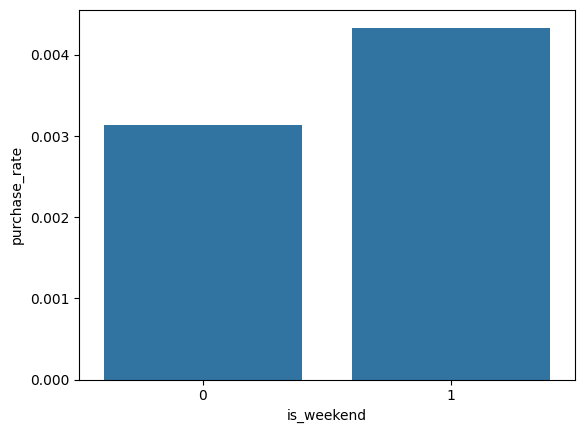

In [55]:
weekend_pd = weekend_eda.toPandas()
sns.barplot(data=weekend_pd, x="is_weekend", y="purchase_rate")




> Finding: On weekends, the purchase rate is marginally higher by about 0.001, and customers also tend to receive slightly more emails in the three days prior to the transaction.

Interpretation: This suggests that customers are slightly more likely to purchase during weekends, potentially influenced by a slightly higher email exposure, though both effects are very small.

Recommendation: While the impact is minimal, weekend-targeted emails or promotions could be tested to see if they generate incremental engagement or purchases.


## Plotting

### Por grupo de edad

In [56]:
# Convertir a pandas
age_summary_pd = age_summary.toPandas()


/tmp/ipykernel_10678/3719838199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


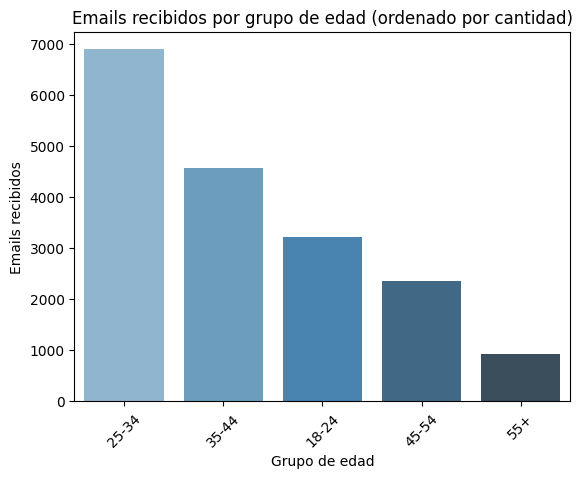

In [57]:
# Ordenamos por valor de emails recibidos (de mayor a menor)
age_order = age_summary_pd.sort_values("emails_received", ascending=False)["age_group"]

sns.barplot(
    data=age_summary_pd,
    x='age_group',
    y='emails_received',
    palette='Blues_d',
    order=age_order
)

plt.title("Emails recibidos por grupo de edad (ordenado por cantidad)")
plt.xlabel("Grupo de edad")
plt.ylabel("Emails recibidos")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_10678/2355850129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


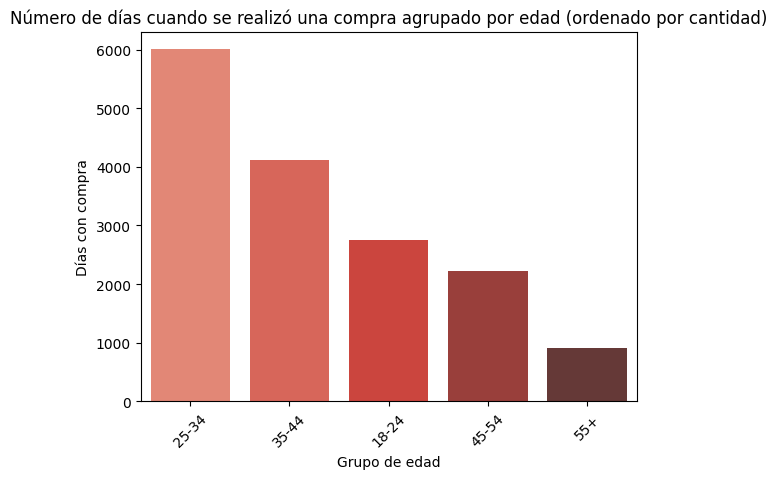

In [58]:
# Ordenamos por días con compra
age_order = age_summary_pd.sort_values("days_with_purchase", ascending=False)["age_group"]

sns.barplot(
    data=age_summary_pd,
    x='age_group',
    y='days_with_purchase',
    palette='Reds_d',
    order=age_order
)

plt.title("Número de días cuando se realizó una compra agrupado por edad (ordenado por cantidad)")
plt.xlabel("Grupo de edad")
plt.ylabel("Días con compra")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_10678/3724384210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


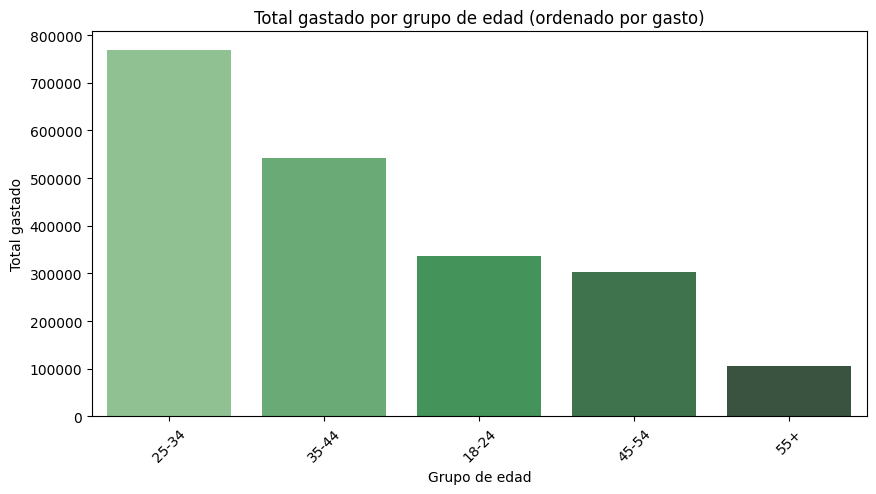

In [59]:
plt.figure(figsize=(10,5))

# Ordenamos por total gastado
age_order = age_summary_pd.sort_values("total_spent", ascending=False)["age_group"]

sns.barplot(
    data=age_summary_pd,
    x='age_group',
    y='total_spent',
    palette='Greens_d',
    order=age_order
)

plt.title("Total gastado por grupo de edad (ordenado por gasto)")
plt.xlabel("Grupo de edad")
plt.ylabel("Total gastado")
plt.xticks(rotation=45)
plt.show()

In [60]:
 # Convertir a Pandas
daily_summary_pd = daily_summary.toPandas()

# Asegurarnos de que la columna de fecha sea datetime
daily_summary_pd['date'] = pd.to_datetime(daily_summary_pd['date'])

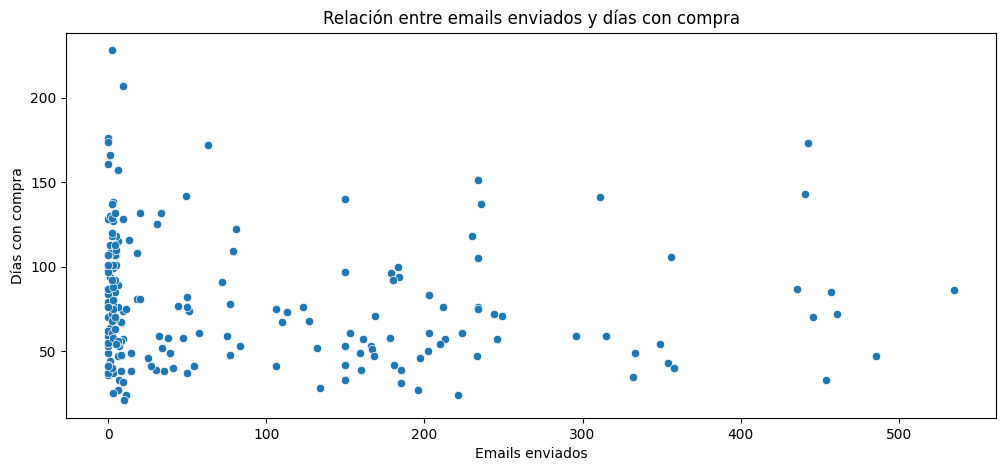

In [61]:
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=daily_summary_pd,
    x='emails_sent',
    y='days_with_purchase'
)
plt.title("Relación entre emails enviados y días con compra")
plt.xlabel("Emails enviados")
plt.ylabel("Días con compra")
plt.show()


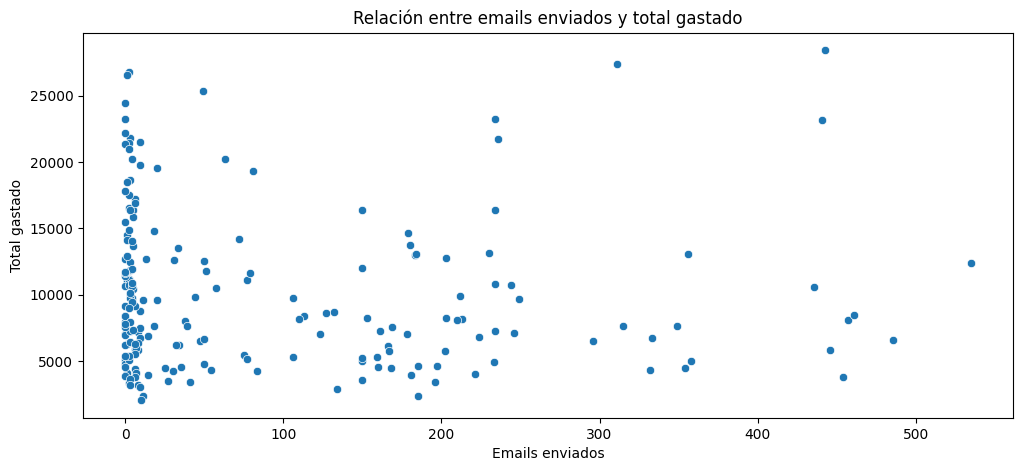

In [62]:
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=daily_summary_pd,
    x='emails_sent',
    y='total_spent'
)
plt.title("Relación entre emails enviados y total gastado")
plt.xlabel("Emails enviados")
plt.ylabel("Total gastado")
plt.show()




> The scope of the current data analysis was determined to span from January 1, 2024, to July 22, 2024.

This period was established due to the overlap of the key data sets: the records for purchase days begin on January 1st, 2024, and the data for emails sent—while starting in mid-2023—is only available up to the final analysis date of July 22, 2024. Therefore, this end date represents the boundary of the comprehensive analysis based on the latest available data across both sources.



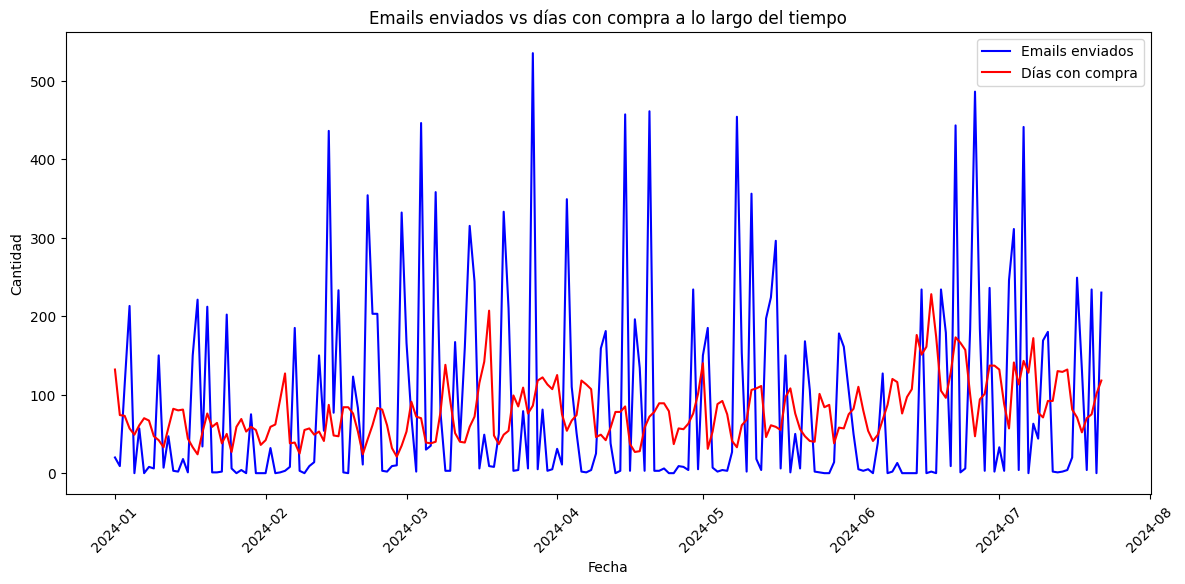

In [63]:
plt.figure(figsize=(14,6))

# Emails enviados
sns.lineplot(data=daily_summary_pd, x='date', y='emails_sent', label='Emails enviados', color='blue')

# Días con compra (escala secundaria)
sns.lineplot(data=daily_summary_pd, x='date', y='days_with_purchase', label='Días con compra', color='red')

plt.title("Emails enviados vs días con compra a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend()
plt.show()


## Regresión

In [64]:
# Selección de features y target
feature_cols = [
    "received_email_last_3days",
    "received_email_last_30days_flag",
    "avg_daily_spent_last_30days",
    "avg_tickets_last_30days",
    "customer_age",
    "is_weekend",
    "is_new_release"
]

# Llenar nulos
customer_day_grid = customer_day_grid.fillna({
    "received_email_last_3days": 0,
    "received_email_last_30days_flag": 0,
    "avg_daily_spent_last_30days": 0.0,
    "avg_tickets_last_30days": 0.0,
    "customer_age": 0,
    "is_weekend": 0,
    "is_new_release": 0
})


A 10% random sample of the dataset is used to reduce computation time while maintaining representativeness. This enables faster model training and analysis (e.g., 5 minutes for 459,681 rows) without losing key patterns, and ensures reproducibility by fixing the seed.

In [65]:
# Tomamos muestra del dataset
sample_fraction = 0.1  # 10% del dataset
data_sample = customer_day_grid.sample(withReplacement=False, fraction=sample_fraction, seed=42)

# Vemos  el tamaño
print(f"Número de filas en la muestra: {data_sample.count()}")


Número de filas en la muestra: 459128


In [66]:
# Vectorización
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_unscaled")
data_sample = assembler.transform(data_sample)
TEMPORAL_CUTOFF = "2024-06-15"  # ~80% del rango ene–jul

train_data_raw = data_sample.filter(col("date") <  F.lit(TEMPORAL_CUTOFF).cast("date"))
test_data_raw  = data_sample.filter(col("date") >= F.lit(TEMPORAL_CUTOFF).cast("date"))

scaler       = StandardScaler(inputCol="features_unscaled", outputCol="features", withMean=True, withStd=True)
scaler_model = scaler.fit(train_data_raw)    # fit solo en train

train_data = scaler_model.transform(train_data_raw)
test_data  = scaler_model.transform(test_data_raw)   # mismo scaler congelado
train_data.cache()

DataFrame[customer_id: string, date: date, received_email: int, received_email_last_3days: bigint, purchased_on_day: int, daily_spent: double, daily_tickets: bigint, customer_age: int, is_new_release: int, avg_daily_spent_last_30days: double, avg_tickets_last_30days: double, received_email_last_30days: bigint, received_email_last_30days_flag: int, last_email_date: date, days_since_last_email: int, is_weekend: int, age_group: string, features_unscaled: vector, features: vector]

In [67]:
# Logistic Regression
log_reg = LogisticRegression(featuresCol="features", labelCol="purchased_on_day")
log_model = log_reg.fit(train_data)
log_pred = log_model.transform(test_data)

In [68]:
# Evaluación
evaluator = BinaryClassificationEvaluator(labelCol="purchased_on_day", rawPredictionCol="rawPrediction")
auc = evaluator.evaluate(log_pred)

print("=== Logistic Regression ===")
print(f"AUC: {auc:.4f}")
print("Coeficientes:", list(zip(feature_cols, log_model.coefficients)))
print("Intercept:", log_model.intercept)


=== Logistic Regression ===
AUC: 0.7737
Coeficientes: [('received_email_last_3days', np.float64(0.01830215054265816)), ('received_email_last_30days_flag', np.float64(0.07430849029153888)), ('avg_daily_spent_last_30days', np.float64(0.10266275483622025)), ('avg_tickets_last_30days', np.float64(-0.5186791112989924)), ('customer_age', np.float64(0.02369131796041102)), ('is_weekend', np.float64(0.28428179661829084)), ('is_new_release', np.float64(1.1120419327038584))]
Intercept: -6.5459528226870445


In [69]:
# Linear Regression
lin_reg = LinearRegression(featuresCol="features", labelCol="daily_spent")
lin_model = lin_reg.fit(train_data)
lin_pred = lin_model.transform(test_data)


In [70]:
# Evaluación
reg_evaluator = RegressionEvaluator(labelCol="daily_spent", predictionCol="prediction", metricName="rmse")
rmse = reg_evaluator.evaluate(lin_pred)
r2 = reg_evaluator.evaluate(lin_pred, {reg_evaluator.metricName: "r2"})

print("\n=== Linear Regression ===")
print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")
print("Coeficientes:", list(zip(feature_cols, lin_model.coefficients)))
print("Intercept:", lin_model.intercept)


=== Linear Regression ===
RMSE: 10.30, R2: 0.2935
Coeficientes: [('received_email_last_3days', np.float64(0.0077896080189700226)), ('received_email_last_30days_flag', np.float64(-0.0033934667900684286)), ('avg_daily_spent_last_30days', np.float64(0.06103033801249347)), ('avg_tickets_last_30days', np.float64(-0.07068803156408862)), ('customer_age', np.float64(0.004464454657632205)), ('is_weekend', np.float64(0.10004509134312035)), ('is_new_release', np.float64(5.017903749047366))]
Intercept: 0.3881376698659884


/tmp/ipykernel_10678/3131567861.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="coefficient", y="feature", data=coef_df, palette="Blues_d")


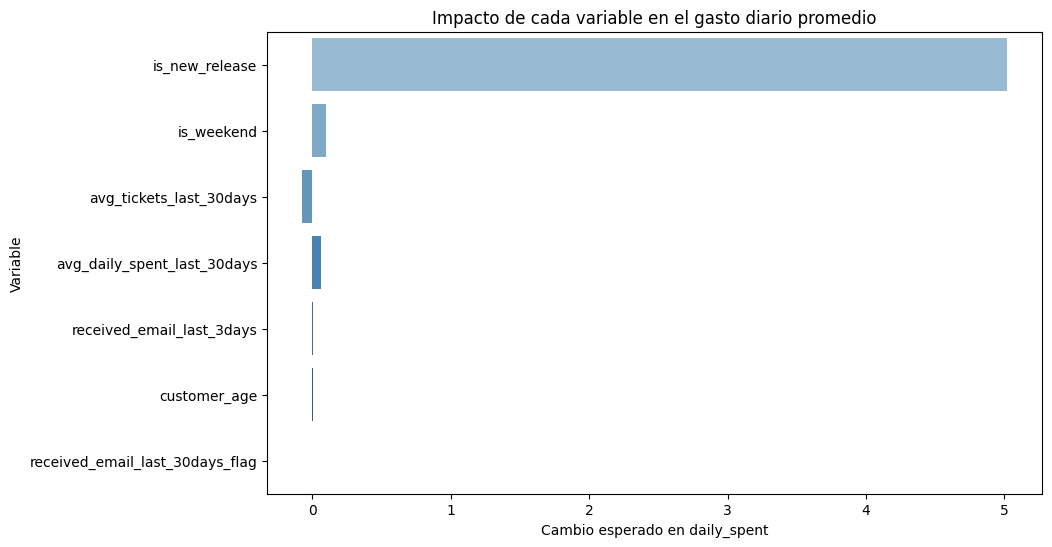

In [71]:
# DataFrame de coeficientes
coef_df = pd.DataFrame({
    "feature": [
        "received_email_last_3days",
        "received_email_last_30days_flag",
        "avg_daily_spent_last_30days",
        "avg_tickets_last_30days",
        "customer_age",
        "is_weekend",
        "is_new_release"
    ],
    "coefficient": list(lin_model.coefficients)
})

# Ordenamos por impacto absoluto descendente
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)

# Graficamos
plt.figure(figsize=(10,6))
sns.barplot(x="coefficient", y="feature", data=coef_df, palette="Blues_d")
plt.title("Impacto de cada variable en el gasto diario promedio")
plt.xlabel("Cambio esperado en daily_spent")
plt.ylabel("Variable")
plt.show()


## Conclussion and final thoughts

Preliminary exploratory analysis suggests that the direct effect of emails on daily spend and purchase probability is relatively low. Simple correlations show that the relationship between the number of emails sent and total spend is nearly zero (`corr = 0.0017`), while the relationship between days since the last email and days with purchases is slightly negative (`corr = -0.025`), indicating no strong association at the aggregate level. However, weekends exhibit higher purchase rates, and movie releases tend to have a positive effect on attendance, aligning with business intuition.
Logistic regression, with an AUC of 0.774, confirms that emails sent in the last three days do not have a significant positive effect on individual purchase probability (`received_email_last_3days`: coef 0.018), whereas receiving an email within the last 30 days shows a slight positive effect (`received_email_last_30days_flag`: coef 0.074). Other factors, such as customer age, weekends, and movie releases, have a more substantial impact on purchase likelihood, particularly releases (`is_new_release:` coef 1.112) and weekends (`is_weekend:` coef 0.284).

Linear regression was used to estimate the quantitative effect of email campaigns and other factors on daily spend per customer. The model explains a moderate portion of the variance in spending (R² = 0.294) with an RMSE of 10.30. Coefficients indicate that recent emails (both within the last three days and within the last 30 days) have minimal impact on daily spend (`received_email_last_3days`: 0.008; `received_email_last_30days_flag`: -0.003), suggesting that sending an email does not directly increase the amount a customer spends on a given day.



In contrast, factors such as recent purchasing behavior significantly affect daily spend. Customers with higher average spend in the last 30 days (`avg_daily_spent_last_30days`: 0.061) show a positive effect, while weekend attendance (`is_weekend`: 0.100) and new movie releases (`is_new_release`: 5.018) also increase spending. Other variables, like age and tickets purchased in the last 30 days, have smaller or slightly negative effects.

The analysis indicates that while email campaigns have a minimal direct impact on customer spending, they still play a role in engagement, as evidenced by slightly higher purchase probabilities in certain segments. Customer behavior factors—such as recent spending history, weekend attendance, and new movie releases—have a much stronger influence on both the likelihood of purchase and the amount spent. These insights suggest that marketing efforts should be strategically targeted toward high-value customers and aligned with weekends or new releases to maximize revenue, while emails can serve as supportive engagement tools rather than primary drivers of immediate sales.